# Проверка качества набора счетов v1

## Краткий итог

Выпуск содержит 50 синтетических счетов в разбиении 30/10/10. После исправления семи повторно использованных ИНН автоматическая проверка не обнаружила ошибок схемы, арифметики, файловой целостности, дубликатов или конфликтов идентичности. Единственное существенное ограничение разбиения: валюты USD, EUR и CNY встречаются только в тестовом разделе. Поэтому итоговые показатели следует публиковать для теста целиком и отдельно для рублевых и нерублевых документов.

## Контекст и метод

Единица наблюдения — один счет, представленный исходным UTF-8 текстом и эталонным JSON. Проверка читает `benchmarks/data/v1/manifest.jsonl`, применяет `schemas/invoice-v1.schema.json`, повторно вычисляет суммы с округлением до копеек, проверяет пары файлов, ключевые значения в тексте, дубликаты, идентичность организаций и SHA-256 выпуска.

Синтетические ИНН должны иметь 10 или 12 цифр. Действительность контрольной цифры не является требованием этого набора и измеряется только как характеристика данных.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

repository_root = Path.cwd().resolve()
sys.path.insert(0, str(repository_root / "src"))

from alice_extractor.dataset_validation import validate_dataset

dataset_root = repository_root / "benchmarks" / "data" / "v1"
schema_path = repository_root / "schemas" / "invoice-v1.schema.json"
report = validate_dataset(dataset_root, schema_path)
assert report.ok, report.errors
report.to_dict()

{'dataset_root': '/Users/nksv_ilya/Documents/Codex/2026-09-11/referenced-chatgpt-conversation-this-is-an/work/alice-extractor-staging/benchmarks/data/v1',
 'record_count': 50,
 'split_counts': {'development': 30, 'test': 10, 'validation': 10},
 'currency_counts': {'CNY': 1, 'EUR': 2, 'RUB': 45, 'USD': 2},
 'vat_mode_counts': {'exempt': 10,
  'mixed_10_20': 2,
  'reduced_10': 8,
  'standard_20': 28,
  'zero_rate': 2},
 'template_counts': {'classic_table': 16,
  'coded_table': 4,
  'compact_table': 4,
  'contract_table': 1,
  'correction_table': 1,
  'discounted_table': 8,
  'export_specification': 1,
  'multiline_table': 2,
  'numbered_list': 4,
  'order_table': 1,
  'payment_request': 1,
  'prepayment_table': 1,
  'reordered_table': 1,
  'sectioned_list': 1,
  'sectioned_table': 1,
  'specification': 1,
  'vat_table': 2},
 'item_count_counts': {'1': 1,
  '2': 7,
  '3': 15,
  '4': 8,
  '5': 9,
  '6': 8,
  '7': 1,
  '8': 1},
 'valid_tax_id_checksums': 7,
 'invalid_tax_id_checksums': 93,


## Данные

In [2]:
records = [
    json.loads(line)
    for line in (dataset_root / "manifest.jsonl").read_text(encoding="utf-8").splitlines()
    if line.strip()
]
frame = pd.DataFrame.from_records(records)

summary = pd.DataFrame(
    {
        "проверка": [
            "записи",
            "ошибки",
            "предупреждения",
            "валидные контрольные цифры ИНН",
            "синтетические ИНН без валидной контрольной цифры",
        ],
        "значение": [
            report.record_count,
            len(report.errors),
            len(report.warnings),
            report.valid_tax_id_checksums,
            report.invalid_tax_id_checksums,
        ],
    }
)
summary

,проверка,значение
0,записи,50
1,ошибки,0
2,предупреждения,1
3,валидные контрольные цифры ИНН,7
4,синтетические ИНН без валидной контрольной цифры,93


## Результаты

In [3]:
split_order = ["development", "validation", "test"]
currency_order = ["RUB", "USD", "EUR", "CNY"]
currency_by_split = (
    pd.crosstab(frame["split"], frame["currency"])
    .reindex(index=split_order, columns=currency_order, fill_value=0)
)
currency_by_split

currency,RUB,USD,EUR,CNY
split,,,,
development,30,0,0,0
validation,10,0,0,0
test,5,2,2,1


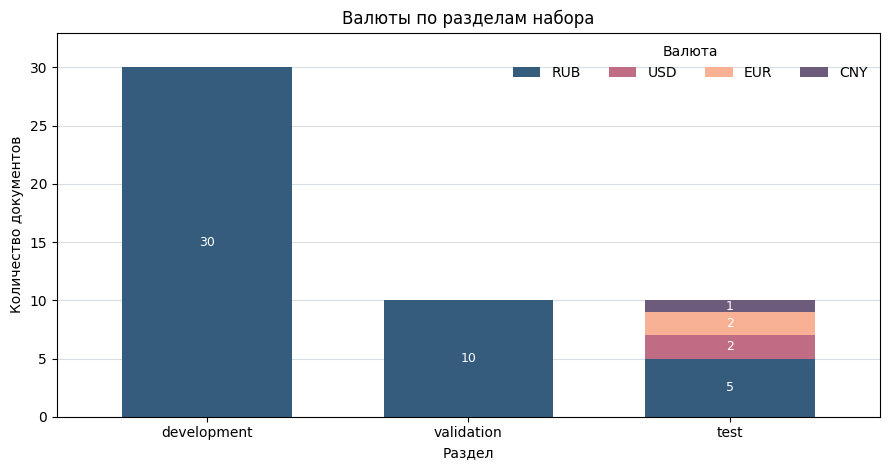

In [4]:
palette = {
    "RUB": "#355C7D",
    "USD": "#C06C84",
    "EUR": "#F8B195",
    "CNY": "#6C5B7B",
}

axis = currency_by_split.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 4.8),
    color=[palette[currency] for currency in currency_by_split.columns],
    width=0.65,
)
axis.set_title("Валюты по разделам набора")
axis.set_xlabel("Раздел")
axis.set_ylabel("Количество документов")
axis.set_ylim(0, 33)
axis.grid(axis="y", color="#D9DEE5", linewidth=0.8)
axis.set_axisbelow(True)
axis.legend(title="Валюта", frameon=False, ncols=4, loc="upper right")
axis.tick_params(axis="x", rotation=0)
for container in axis.containers:
    labels = [f"{int(value)}" if value else "" for value in container.datavalues]
    axis.bar_label(container, labels=labels, label_type="center", color="white", fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
template_coverage = (
    pd.crosstab(frame["template_family"], frame["split"])
    .reindex(columns=split_order, fill_value=0)
    .sort_values(split_order, ascending=False)
)
template_coverage

split,development,validation,test
template_family,,,
classic_table,15,0,1
discounted_table,4,3,1
compact_table,2,0,2
numbered_list,2,0,2
multiline_table,2,0,0
coded_table,1,3,0
vat_table,1,0,1
correction_table,1,0,0
prepayment_table,1,0,0


## Выводы

- Состав выпуска соответствует заявленному разбиению и все 50 эталонов проходят JSON Schema.
- Сумма позиций, подытог, НДС и итог согласованы для всех документов.
- Точных и нормализованных дубликатов нет. После исправления не осталось повторных ИНН и конфликтов между названиями организаций и идентификаторами.
- SHA-256 фиксирует манифест и 100 файлов с текстами и эталонами.
- 93 из 100 синтетических ИНН намеренно не проходят официальный алгоритм контрольной цифры. Набор подходит для оценки извлечения строки, но не для оценки действительности ИНН.
- Нерублевые валюты находятся только в тесте. Общий результат нужно дополнять отдельными показателями для RUB и остальных валют.

Источник проверки: локальные файлы `benchmarks/data/v1`, схема `schemas/invoice-v1.schema.json` и код `src/alice_extractor/dataset_validation.py`.